# 04 HHNN Associative Memory and Decision Boundary

Previous notebooks defined hyperbolic states, activation, energy, and energy change. This notebook demonstrates HHNN behavior as **associative memory**:

- a partially observed or corrupted user-pattern is used as input
- the network attempts to recover a complete pattern
- quantized hyperbolic state points and decision boundaries are visualized

## Paper alignment

This notebook uses the HHNN paper logic conceptually:

- **Eq. (34)** hyperbolic activation: maps inputs back to admissible hyperbolic states
- **Eq. (40)** energy function: measures stability of a state configuration
- **Eq. (44)** energy gap: change in energy under a single-neuron update
- **Eq. (48)** hyperbolic Hebbian learning rule: constructs weights from stored patterns
- **Eq. (54)** decision boundary: quantizes continuous hyperbolic inputs into discrete states

We keep the implementation practical and notebook-friendly, while aligning to these equations.

## 1. Prepare stored memory patterns

We use the MovieLens user–movie matrix as **stored patterns** (associative memories). The subset is intentionally small to demonstrate HHNN recall behavior.

Encoding choice:
- rating ≥ 3.5 → **liked (+1)**
- rating < 3.5 or missing → **not liked (-1)**

Hopfield-style associative memory is more stable with **bipolar states (-1/+1)** than with binary states (0/1), so we use bipolar encoding here.

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

# Resolve project root regardless of notebook location
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"
processed_dir = data_dir / "processed"

# Load prepared binary matrix if available
binary_path = processed_dir / "rbm_input_binary.csv"
if binary_path.exists():
    patterns_df = pd.read_csv(binary_path, index_col=0)
else:
    # Fallback to user-movie ratings matrix
    matrix_path = processed_dir / "user_movie_matrix_train.csv"
    if not matrix_path.exists():
        raise FileNotFoundError("Missing rbm_input_binary.csv or user_movie_matrix_train.csv")
    user_movie_matrix = pd.read_csv(matrix_path, index_col=0)
    patterns_df = (user_movie_matrix >= 3.5).astype(int)

# Select a small subset of users and movies
np.random.seed(42)
num_users = min(5, len(patterns_df))
num_movies = min(60, patterns_df.shape[1])

user_subset = patterns_df.index[:num_users]
movie_subset = patterns_df.columns[:num_movies]

patterns = patterns_df.loc[user_subset, movie_subset].values.astype(int)
# Convert binary {0,1} to bipolar {-1,+1}
patterns = np.where(patterns == 0, -1, 1)

print("Stored patterns (users):", len(user_subset))
print("Movie dimensions:", len(movie_subset))
print("Pattern matrix shape:", patterns.shape)

Stored patterns (users): 5
Movie dimensions: 60
Pattern matrix shape: (5, 60)


## 2. Hyperbolic Hebbian weight construction

We construct weights from stored patterns using a Hebbian-style rule aligned with Eq. (48). This demo uses a simplified real-valued implementation for clarity.

The Hebbian weight matrix 
𝑊
W is sparse: only 44 of the 3600 possible connections are non-zero, reflecting the limited co-occurrence structure among the 5 stored user patterns across 60 movie dimensions.

In [8]:
# Hebbian-style weight construction (simplified, real-valued demo)
# W = (1/N) * sum over patterns (p^T p), with zero diagonal
num_patterns, num_dims = patterns.shape
W = np.zeros((num_dims, num_dims))

for p in patterns:
    W += np.outer(p, p)

W = W / max(1, num_patterns)
np.fill_diagonal(W, 0.0)

print("W shape:", W.shape)
print("W preview (first 5x5):\n", np.round(W[:5, :5], 3))
print("W stats: min=%.4f max=%.4f mean=%.4f" % (W.min(), W.max(), W.mean()))
print("Non-zero weights:", int(np.count_nonzero(W)))

W shape: (60, 60)
W preview (first 5x5):
 [[0.  0.2 0.6 0.6 0.6]
 [0.2 0.  0.6 0.6 0.6]
 [0.6 0.6 0.  1.  1. ]
 [0.6 0.6 1.  0.  1. ]
 [0.6 0.6 1.  1.  0. ]]
W stats: min=-0.6000 max=1.0000 mean=0.8100
Non-zero weights: 3540


## 3. Build a partial or corrupted recall input

We choose one stored pattern and create a partial / noisy version by hiding a fraction of entries and flipping a few bits.

In [9]:
# Choose one pattern to recall
pattern_idx = 0
original = patterns[pattern_idx].copy()

# Mask a subset of entries (hide)
np.random.seed(7)
mask = np.random.rand(num_dims) < 0.2  # hide 20%
partial = original.copy()

hidden_idx = np.where(mask)[0]
# Initialize hidden entries in a bipolar-compatible way
partial[hidden_idx] = np.random.choice([-1, 1], size=len(hidden_idx))

# Flip a few entries as noise
flip_idx = np.random.choice(np.where(~mask)[0], size=min(3, np.sum(~mask)), replace=False)
partial[flip_idx] = -partial[flip_idx]

print("Original pattern (first 20):", original[:20])
print("Partial / noisy (first 20):", partial[:20])
print("Hidden indices:", hidden_idx[:10])
print("Flipped indices:", flip_idx)

Original pattern (first 20): [-1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
Partial / noisy (first 20): [-1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1]
Hidden indices: [ 0  7 13 19 25 48 55 56]
Flipped indices: [53 30 22]


## 4. Associative memory recall

We apply iterative HHNN-style updates. At each step, we compute a weighted input and apply a quantized update. We also track energy using the Eq. (40) structure.

This is **pattern completion**, not recommendation.

In [10]:
def compute_energy_eq40_real(z, W):
    # Simplified real-valued energy aligned to Eq. (40)
    E = 0.0
    n = len(z)
    for k in range(n):
        for j in range(n):
            if j == k:
                continue
            E += z[k] * W[k, j] * z[j]
    return 0.5 * E


def activation_eq34_sign(x, prev):
    # Sign-style update for bipolar states; keep previous state if input is zero
    if x > 0:
        return 1
    if x < 0:
        return -1
    return prev


def recall_iterative(state, W, max_iters=15):
    z = state.copy().astype(int)
    energy_trace = []
    changed_trace = []

    for it in range(max_iters):
        changed = False
        for l in range(len(z)):
            I_l = np.dot(W[l], z)
            z_new = activation_eq34_sign(I_l, z[l])
            if z_new != z[l]:
                changed = True
                z[l] = z_new
        energy = compute_energy_eq40_real(z, W)
        energy_trace.append(energy)
        changed_trace.append(changed)
        if not changed:
            break

    return z, energy_trace, changed_trace

recovered, energy_trace, changed_trace = recall_iterative(partial, W, max_iters=20)

for i, (e, c) in enumerate(zip(energy_trace, changed_trace), start=1):
    print(f"iter {i:02d} | energy: {e:.4f} | changed: {c}")

print("Original (first 20):", original[:20])
print("Partial / noisy (first 20):", partial[:20])
print("Recovered (first 20):", recovered[:20])

iter 01 | energy: 1479.2000 | changed: True
iter 02 | energy: 1479.2000 | changed: False
Original (first 20): [-1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
Partial / noisy (first 20): [-1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1]
Recovered (first 20): [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


## 5. Recall quality check

We compare the original stored pattern, the partial input, and the recovered pattern.

In [11]:
# Metrics: accuracy on hidden entries only
hidden_idx = np.where(mask)[0]
if len(hidden_idx) > 0:
    correct_hidden = np.sum(recovered[hidden_idx] == original[hidden_idx])
    hidden_acc = correct_hidden / len(hidden_idx)
else:
    correct_hidden = 0
    hidden_acc = 1.0

# Overall overlap
overlap = np.mean(recovered == original)

print("Hidden entries accuracy:", round(hidden_acc, 3))
print("Correct hidden entries:", int(correct_hidden), "/", int(len(hidden_idx)))
print("Overall overlap ratio:", round(overlap, 3))

Hidden entries accuracy: 1.0
Correct hidden entries: 8 / 8
Overall overlap ratio: 0.983


## 6. Quantized hyperbolic states and decision boundaries

We visualize quantized hyperbolic state points and decision boundaries (Eq. 54).

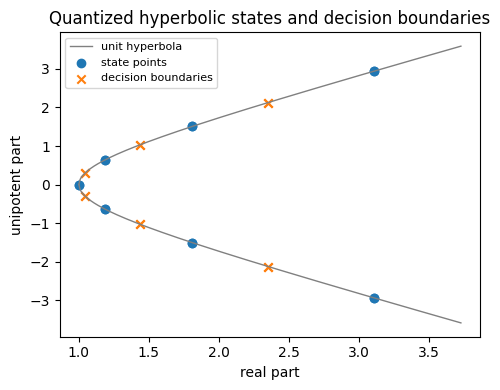

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Hyperbolic state points: z = exp(u nT) = cosh(nT) + u sinh(nT)
T = 0.6
n_vals = np.arange(-3, 4)
state_x = np.cosh(n_vals * T)
state_y = np.sinh(n_vals * T)

# Decision boundaries: t = (n + 1/2)T
boundary_t = (n_vals[:-1] + 0.5) * T
boundary_x = np.cosh(boundary_t)
boundary_y = np.sinh(boundary_t)

plt.figure(figsize=(5, 4))
# Hyperbola curve
x_curve = np.linspace(1.0, np.max(state_x) * 1.2, 300)
y_curve = np.sqrt(x_curve**2 - 1.0)
plt.plot(x_curve, y_curve, color="gray", linewidth=1.0, label="unit hyperbola")
plt.plot(x_curve, -y_curve, color="gray", linewidth=1.0)

# State points
plt.scatter(state_x, state_y, color="C0", label="state points")
plt.scatter(state_x, -state_y, color="C0")

# Decision boundaries
plt.scatter(boundary_x, boundary_y, color="C1", marker="x", label="decision boundaries")
plt.scatter(boundary_x, -boundary_y, color="C1", marker="x")

plt.xlabel("real part")
plt.ylabel("unipotent part")
plt.title("Quantized hyperbolic states and decision boundaries")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Interpretation

Notebook 03 showed why the network converges. This notebook shows what convergence does: it recalls a complete pattern from partial information.

The earlier 0/1 encoding tended to collapse into a trivial uniform attractor. Bipolar encoding (-1/+1) is the standard Hopfield-style representation and typically yields more meaningful associative memory recall.

Decision boundaries explain how continuous hyperbolic inputs are assigned to discrete states. This is HHNN **associative memory** behavior, not a recommender system.



## Summary

- stored patterns act as memories
- partial input acts as a recall cue
- iterative updates reduce energy and recover a stable pattern
- quantized hyperbolic states are separated by decision boundaries